<a href="https://colab.research.google.com/github/RileyMarek/NasaRoverVLModel/blob/main/Marek_AutonomousRoverSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NASA Rover Research Project**
****
**ML Model: Vision-Language segmentaion using U-Net Architecture**

Student: Riley Marek

WSUID: 11843302

Project Proposal:

https://emailwsu-my.sharepoint.com/:w:/g/personal/riley_marek_wsu_edu/IQBLEOWgFzYdSo3YjrjukNyjAarehlioB3FybL-p5Mr0PpE?e=OBSQDD



Google Drive with Model and Output Data:

https://drive.google.com/drive/folders/1PcJ1xl160CGjD9eLjiX6zrBuVxYZVgop?usp=sharing



In [1]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Google Colab/LRO_Project"
os.makedirs(save_path, exist_ok=True)



Mounted at /content/drive


In [2]:
# Install necessary libraries
!pip install -q segmentation-models-pytorch albumentations transformers torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.2 MB/s eta 0:00:00


**Data Processing:**
****

In [49]:
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class LunarTerrainDataset(Dataset):
  def __init__(self, image_paths, dem_paths, transform=None):
    self.image_paths = image_paths
    self.dem_paths = dem_paths
    self.transform = transform

    # Initialize CLAHE for lunar contrast normalization
    self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):

    #  Load processed PNG (already normalized, correct dimensions)
    image = cv2.imread(self.image_paths[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load raw .IMG using PDS label for correct dimensions
    dem_path = self.dem_paths[idx]
    rows, cols, offset = parse_pds_label(dem_path)

    crop = 2048
    row_start = max(0, (rows - crop) // 2)
    col_start = max(0, (cols - crop) // 2)
    actual_rows = min(crop, rows)
    actual_cols = min(crop, cols)

    with open(dem_path, "rb") as f:
        f.seek(offset)
        raw_data = np.frombuffer(f.read(rows * cols), dtype=np.uint8).reshape((rows, cols))

    # Resize DEM to match image for mask generation
    dem_data = cv2.resize(raw_data, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)

    #  Prompt & mask
    prompt, weights = get_dynamic_prompt()
    mask = generate_hazard_mask(dem_data, image, weights)

    # CLAHE contrast enhancement
    image_bw = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    image_bw = self.clahe.apply(image_bw)
    image = cv2.cvtColor(image_bw, cv2.COLOR_GRAY2RGB)

    # Augmentations
    if self.transform:
        augmented = self.transform(image=image, mask=mask)
        image = augmented['image']
        mask = augmented['mask']

    if isinstance(mask, np.ndarray):
        mask = torch.from_numpy(mask).float().unsqueeze(0)

    return image, mask, prompt


    return image, mask, prompt


# -- Define Albumentation Strategy --
train_transform = A.Compose(
    [
        A.Resize(height=224, width=224),

        # Simulate Lunar Shadows (for lunar nav)
        A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_limit=(1,2), shadow_dimension=5, p=0.5),

        # Add Gaussian Noise to simulate sensor limitations
        A.GaussNoise(std_range=(0.1, 0.2), p=0.3),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Normalize(
            mean=(0.48145466, 0.4578275, 0.40821073),
            std=(0.26862954, 0.26130258, 0.27577711)
        ),
        ToTensorV2(),
    ]
)


**FiLM Layer:**
****

In [4]:
import torch
import torch.nn as nn

class FiLMLayer(nn.Module):
  def __init__(self, text_emb_dim, feature_channels):
    super().__init__()
    # Generate gamma (scale) and beta (shift) from text embedding
    self.generator = nn.Linear(text_emb_dim, 2 * feature_channels)

  def forward(self, x, text_embedding):
    # x shape: [Batch, Channels, H, W]
    # text_embedding shape: [Batch, text_emb_dim]

    # Predict parameters
    params = self.generator(text_embedding)
    params = params.unsqueeze(-1).unsqueeze(-1) # [Batch, 2*feature_channels, 1, 1]
    gamma, beta = torch.chunk(params, chunks=2, dim=1)

    # Apply Afine transformation: (gamma * x) + beta
    return gamma * x + beta


**Multi-Modal (Vision-Language) U-Net Architecture:**
****

In [46]:
from transformers import CLIPVisionModel, CLIPTextModel, CLIPProcessor
import inspect
from segmentation_models_pytorch.decoders.unet.decoder import UnetDecoder

class VLUNet(nn.Module):
  def __init__(self, num_classes=1):
    super().__init__()

    # Frozen encoders (might fine-tune later depending on compute req)
    self.vision_encoder = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch16')
    self.text_encoder = CLIPTextModel.from_pretrained('openai/clip-vit-base-patch16')

    for param in self.vision_encoder.parameters(): param.requires_grad = False
    for param in self.text_encoder.parameters(): param.requires_grad = False

    # FiLM conditioning at Bottleneck
    # CLIPTextModel with patch16 has hidden size 512, pooler_output is 512
    self.bottleneck_film = FiLMLayer(text_emb_dim=512, feature_channels=768)

    # SMP decoder
    self.decoder = UnetDecoder(
        encoder_channels=[768, 768, 768, 768, 768],
        decoder_channels=[256, 128, 64, 32, 16],
        n_blocks=5,
    )

    self.upsample = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)

    self.segmentation_head = nn.Conv2d(32, num_classes, kernel_size=1)

  def forward(self, pixel_values, input_ids, attention_mask):
    text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
    text_emb = text_outputs.pooler_output

    vision_outputs = self.vision_encoder(
        pixel_values=pixel_values,
        output_hidden_states=True
    )
    raw_layers = [vision_outputs.hidden_states[i] for i in [3, 6, 9, 11, 12]]

    target_sizes = [128, 64, 32, 16, 8]
    h_feat = []
    for i, layer in enumerate(raw_layers):
        B, seq_len, C = layer.shape
        grid = int((seq_len - 1) ** 0.5)  # drop CLS token, compute grid
        feat = layer[:, 1:, :].transpose(1, 2).view(B, C, grid, grid)
        feat = F.interpolate(feat, size=(target_sizes[i], target_sizes[i]), mode='bilinear', align_corners=False)
        if i == 0:
            feat = self.bottleneck_film(feat, text_emb)
        h_feat.append(feat)

    x = self.decoder(h_feat[::-1])
    x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
    return self.segmentation_head(x)

**Hybrid Loss Function**
****
Binary Cross-Entropy for pixel-wise confidence

Dice-Loss for regional overlap

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceBCELoss(nn.Module):
  def __init__(self, weight=None, size_average=True):
    super(DiceBCELoss, self).__init__()

  def forward(self, inputs, targets, smooth=1):

    # flatten label and prediction tensors
    inputs = torch.sigmoid(inputs)
    inputs = inputs.view(-1)
    targets = targets.view(-1)

    # Dice Loss
    intersection = (inputs * targets).sum()
    dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

    # Binary Cross-Entropy
    BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')

    # Combine
    return BCE + dice_loss


**Pull LRO Data**
****

In [7]:
import os
import requests
import numpy as np
import cv2
from tqdm.notebook import tqdm
import os, io, requests
import pandas as pd
import numpy as np
import cv2
from tqdm.notebook import tqdm


# ── PDS LABEL PARSER ────────────────────────────────────────────────────────
def parse_pds_label(image_path):
    rows, cols, record_bytes, label_records = None, None, None, None
    with open(image_path, "rb") as f:
        for line in f:
            text = line.decode("ascii", errors="ignore").strip()
            if "LINES " in text and "=" in text:
                rows = int(text.split("=")[1].strip())
            elif "LINE_SAMPLES" in text and "=" in text:
                cols = int(text.split("=")[1].strip())
            elif "RECORD_BYTES" in text and "=" in text:
                record_bytes = int(text.split("=")[1].strip())
            elif "LABEL_RECORDS" in text and "=" in text:
                label_records = int(text.split("=")[1].strip())
            elif text == "END":
                break
    offset = (label_records * record_bytes) if (label_records and record_bytes) else 0
    return rows, cols, offset




def fetch_volume_index(volume="LROLRC_0012", max_images=50, nac_only=True):
    """
    Fetch CUMINDEX.TAB and extract only paths that belong to the requested
    volume, stripping fixed-width whitespace padding correctly.
    """
    base = "https://pds.lroc.im-ldi.com/data/LRO-L-LROC-2-EDR-V1.0"
    index_url = f"{base}/{volume}/INDEX/CUMINDEX.TAB"

    print(f"Fetching index from {index_url} ...")
    r = requests.get(index_url, timeout=60, stream=True)
    r.raise_for_status()

    paths = []
    for line in r.iter_lines():
        text = line.decode("ascii", errors="ignore")
        # Each field is quoted and comma-separated; strip ALL whitespace per field
        parts = [p.strip().strip('"').strip() for p in text.split(",")]

        # Find the .IMG path field
        img_path = next((p for p in parts if p.upper().endswith(".IMG")), None)
        if not img_path:
            continue

        # ✅ Only keep paths that actually belong to THIS volume
        if volume not in img_path:
            continue

        # ✅ Optionally filter to NAC only (skip WAC — CE suffix = WAC)
        if nac_only and "/WAC/" in img_path.upper():
            continue

        # Extract just the relative part starting from the volume name
        # e.g. "LROLRC_0012/DATA/SCI/2012240/NAC/M1100702598RE.IMG"
        idx = img_path.find(volume)
        clean_path = img_path[idx:]  # strip any leading garbage/spaces

        paths.append(clean_path)
        if len(paths) >= max_images:
            break

    print(f"  Found {len(paths)} usable NAC paths in {volume}.")
    return paths


def build_url(clean_path):
    base = "https://pds.lroc.im-ldi.com/data/LRO-L-LROC-2-EDR-V1.0"
    return f"{base}/{clean_path}"


def download_lro_bulk(volume="LROLRC_0012", max_images=50, save_dir="lro_data"):
    os.makedirs(save_dir, exist_ok=True)

    img_paths = fetch_volume_index(volume, max_images=max_images, nac_only=True)
    if not img_paths:
        print("❌ No usable images found. Try a different volume.")
        return

    succeeded = 0
    for clean_path in img_paths:
        image_id = os.path.basename(clean_path).replace(".IMG", "")
        save_path = os.path.join(save_dir, f"{image_id}.IMG")

        if os.path.exists(save_path):
            print(f"[{image_id}] Already exists, skipping.")
            succeeded += 1
            continue

        url = build_url(clean_path)
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            with open(save_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=image_id, leave=False) as bar:
                for chunk in r.iter_content(chunk_size=65536):
                    f.write(chunk)
                    bar.update(len(chunk))
            print(f"[{image_id}] ✅ Saved.")
            succeeded += 1
        except requests.HTTPError as e:
            print(f"[{image_id}] ❌ {e}")
        except Exception as e:
            print(f"[{image_id}] ❌ {e}")

    print(f"\nDone. {succeeded}/{len(img_paths)} images ready in '{save_dir}/'")

**Model Training Logic**
****

In [54]:
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import JaccardIndex, F1Score
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device, tokenizer, scaler, is_vl=True):
  model.train()
  total_loss = 0.0

  # Binary Metrics
  iou_metric = JaccardIndex(task="binary").to(device)
  f1_metric = F1Score(task="binary").to(device)

  pbar = tqdm(dataloader, desc="Training")
  for images, masks, prompts in pbar:

    # Move to GPU
    images = images.to(device)

    if masks.dim() == 3:
      masks = masks.unsqueeze(1)
    masks = masks.to(device).float()

    # Forward Pass
    optimizer.zero_grad()
    with torch.amp.autocast('cuda'):
      if is_vl:
        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
        outputs = model(images, inputs['input_ids'], inputs['attention_mask'])
      else:
        outputs = model(images)

      # Calculate Loss
      loss = criterion(outputs, masks)


    # Backwards Pass (scaled for T4 stability)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Update Metrics
    with torch.no_grad():
      preds = (torch.sigmoid(outputs) > 0.5).float()
      iou_metric.update(preds, masks.int())
      f1_metric.update(preds, masks.int())

    total_loss += loss.item()
    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "IoU": f"{iou_metric.compute().item():.4f}"
        })

  return total_loss / len(dataloader), iou_metric.compute().cpu().item(), f1_metric.compute().cpu().item()



**Generate Dynamic Ground-Truth labels with LOLA DEM**
****
LOLA (Lunar Orbiter Laser Altimeter)

DEM (Digital Evaluation Model) data for each LRO image

In [9]:
import numpy as np
import torch

def generate_hazard_mask(dem_array, image_array, weights):
  """
  dem_array:   2D numpy array (H, W) — raw DEM data
  image_array: 3D numpy array (H, W, 3) — RGB image
  weights:     dict like {'slope': 0.7, 'shadow': 0.2, 'roughness': 0.1}
  """
  dem = dem_array.astype(float)

  # ── Slope hazard ─────────────────────────────────────────────────────
  dx, dy = np.gradient(dem)
  slope = np.sqrt(dx**2 + dy**2)
  slope_degrees = np.degrees(np.arctan(slope))
  hazard_slope = np.clip(slope_degrees / 30.0, 0, 1)  # shape (H, W)

  # ── Shadow hazard ─────────────────────────────────────────────────────
  gray = cv2.cvtColor(image_array.astype(np.uint8), cv2.COLOR_RGB2GRAY)
  hazard_shadow = 1.0 - (gray.astype(float) / 255.0)
  hazard_shadow = np.clip(hazard_shadow, 0, 1)          # shape (H, W)

  # ── Roughness hazard — std dev of DEM in local 5×5 neighborhood ──────
  from scipy.ndimage import uniform_filter
  dem_mean = uniform_filter(dem, size=5)
  dem_sq_mean = uniform_filter(dem**2, size=5)
  roughness = np.sqrt(np.maximum(dem_sq_mean - dem_mean**2, 0))
  # Normalize: clip at 95th percentile so outliers don't dominate
  p95 = np.percentile(roughness, 95)
  hazard_roughness = np.clip(roughness / (p95 + 1e-6), 0, 1)  # shape (H, W)

  # ── Resize all maps to match image size if needed ─────────────────────
  target_shape = (image_array.shape[0], image_array.shape[1])
  def resize_if_needed(arr):
      if arr.shape != target_shape:
          return cv2.resize(arr, (target_shape[1], target_shape[0]),
                            interpolation=cv2.INTER_LINEAR)
      return arr

  hazard_slope     = resize_if_needed(hazard_slope)
  hazard_shadow    = resize_if_needed(hazard_shadow)
  hazard_roughness = resize_if_needed(hazard_roughness)

  # ── Combine with weights (missing keys default to 0.0) ───────────────
  total_hazard = (
      weights.get('slope',     0.0) * hazard_slope +
      weights.get('shadow',    0.0) * hazard_shadow +
      weights.get('roughness', 0.0) * hazard_roughness
  )

  return np.clip(total_hazard, 0, 1).astype(np.float32)


def generate_lola_mask(dem_array, resolution_meters=118.0, slope_threshold=15.0):
  """
  dem_array: 2D numpy array of elevation values.
  resolution_meters: The spatial resolution of the DEM (m/pixel).
  slope_threshold: The degree at which terrain becomes 'hazardous'.
  """

  # Calculate gradient
  dx, dy = np.gradient(dem_array, resolution_meters)

  # Calculate slope magnitude
  slope = np.sqrt(dx**2 + dy**2)

  # Convert to degrees
  slope_deg = np.degrees(np.arctan(slope))

  # Create binary mask: 1 for hazardous (Slope > Threshold), 0 for Safe
  mask = (slope_deg > slope_threshold).astype(np.uint8)

  return mask, slope_deg


**Baseline Vision-only CLIP UNet Model**
****

In [47]:
import segmentation_models_pytorch as smp
import inspect
from segmentation_models_pytorch.decoders.unet.decoder import UnetDecoder


# Same CLIP model for vision only (same architecture backbone)
class VisionOnlyUNet(nn.Module):
  def __init__(self, num_classes=1):
    super().__init__()

    # Frozen encoders (might fine-tune later depending on compute req)
    self.vision_encoder = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch16')

    for param in self.vision_encoder.parameters(): param.requires_grad = False


    # SMP decoder
    self.decoder = UnetDecoder(
        encoder_channels=[768, 768, 768, 768, 768],
        decoder_channels=[256, 128, 64, 32, 16],
        n_blocks=5,
    )

    self.upsample = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)

    self.segmentation_head = nn.Conv2d(32, num_classes, kernel_size=1)

  def forward(self, pixel_values):
    vision_outputs = self.vision_encoder(
        pixel_values=pixel_values,
        output_hidden_states=True
    )
    raw_layers = [vision_outputs.hidden_states[i] for i in [3, 6, 9, 11, 12]]

    target_sizes = [128, 64, 32, 16, 8]
    h_feat = []
    for i, layer in enumerate(raw_layers):
        B, seq_len, C = layer.shape
        grid = int((seq_len - 1) ** 0.5)  # drop CLS token, compute grid
        feat = layer[:, 1:, :].transpose(1, 2).view(B, C, grid, grid)
        feat = F.interpolate(feat, size=(target_sizes[i], target_sizes[i]), mode='bilinear', align_corners=False)
        h_feat.append(feat)

    x = self.decoder(h_feat[::-1])
    x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
    return self.segmentation_head(x)


**Plotting  Data Helper**
****

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def plot_results(history):
  metrics = ['loss', 'iou', 'f1']
  plt.figure(figsize=(15, 5))

  for i, metric in enumerate(metrics):
      plt.subplot(1, 3, i + 1)


      baseline_vals = [v.cpu().item() if hasattr(v, 'cpu') else float(v) for v in history['baseline'][metric]]
      vl_vals       = [v.cpu().item() if hasattr(v, 'cpu') else float(v) for v in history['vl'][metric]]

      plt.plot(baseline_vals, label='Baseline (Vision Only)',     color='blue',  linestyle='--')
      plt.plot(vl_vals,       label='Proposed (Vision-Language)', color='green')
      plt.title(f'Comparison of {metric.upper()}')
      plt.xlabel('Epochs')
      plt.ylabel(metric.capitalize())
      plt.legend()
      plt.grid(True)

  plt.tight_layout()
  save_file = f"{save_path}/training_metrics_history.png"
  plt.savefig(save_file, bbox_inches='tight', dpi=300)
  print(f"Metrics plot saved to: {save_file}")
  plt.show()

**Feature Map Visual**
****

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_nav_grid(model_vl, model_baseline, dataloader, device, num_samples=3):
  model_vl.eval()
  model_baseline.eval()

  images, masks, prompts = next(iter(dataloader))

  num_samples = min(num_samples, images.shape[0])

  fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))

  if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

  with torch.no_grad():
    for i in range(num_samples):

      # Prepare Input Tensors
      img_tensor = images[i].unsqueeze(0).to(device)
      mask_np = masks[i].squeeze().cpu().numpy()
      prompt = prompts[i]

      tokens = tokenizer([prompt], return_tensors="pt", padding=True).to(device)

      # Get Predictions
      out_vl = model_vl(img_tensor, tokens['input_ids'], tokens['attention_mask'])
      pred_vl = torch.sigmoid(out_vl).squeeze().cpu().numpy()


      out_base = model_baseline(img_tensor)
      pred_base = torch.sigmoid(out_base).squeeze().cpu().numpy()

      # Image De-normalization for Display
      img_display = images[i].permute(1, 2, 0).cpu().numpy()
      mean = np.array([0.481, 0.457, 0.408])
      std = np.array([0.268, 0.261, 0.275])
      img_display = (img_display * std) + mean
      img_display = np.clip(img_display, 0, 1)

      # Plotting
      # --- Column 1: Ground Truth Overlay (Dynamic Mask) ---
      axes[i, 0].imshow(img_display)
      axes[i, 0].imshow(mask_np, cmap='magma', alpha=0.5)
      axes[i, 0].set_title(f"Sample {i+1}: Target Mask\n{prompt}")

      # --- Column 2: Baseline Overlay ---
      axes[i, 1].imshow(img_display)
      axes[i, 1].imshow(pred_base, cmap='jet', alpha=0.4)
      axes[i, 1].set_title(f"Baseline Prediction\n(Vision Only)")

      # --- Column 3: Vision-Language Overlay ---
      axes[i, 2].imshow(img_display)
      axes[i, 2].imshow(pred_vl, cmap='jet', alpha=0.4)
      axes[i, 2].set_title(f"VL Prediction\nPrompt: {prompt}")

      for j in range(3):
        axes[i, j].axis('off')


  plt.tight_layout()
  save_file = f"{save_path}/model_comparison_visual_results.png"
  plt.savefig(save_file, bbox_inches='tight', dpi=300)
  print(f"Results saved to: {save_file}")
  plt.show()

In [13]:
import random

def get_dynamic_prompt():
  templates = [
        "Navigate while avoiding {adj} {feature}",
        "Find a path away from {feature}",
        "Identify {adj} {feature} for rover safety",
        "Map out all {feature} that are {adj}",
        "Where are the {adj} {feature} located?"
    ]

  options = [
      {"feature": "slopes",  "adj": "steep",     "weights": {'slope': 1.0, 'shadow': 0.0, 'roughness': 0.0}},
      {"feature": "shadows", "adj": "dark",       "weights": {'slope': 0.0, 'shadow': 1.0, 'roughness': 0.0}},
      {"feature": "terrain", "adj": "hazardous",  "weights": {'slope': 0.6, 'shadow': 0.4, 'roughness': 0.0}},
      {"feature": "rocks",   "adj": "rough",      "weights": {'slope': 0.0, 'shadow': 0.0, 'roughness': 1.0}},
      {"feature": "terrain", "adj": "rugged",     "weights": {'slope': 0.3, 'shadow': 0.2, 'roughness': 0.5}},
  ]

  choice = random.choice(options)
  prompt = random.choice(templates).format(feature=choice['feature'], adj=choice['adj'])

  return prompt, choice['weights']

**Initialize DataLoaders**
****

In [15]:

target_images = ["M1424186468LE", "M1100702598RE", "M1100702598LE"]

download_lro_bulk(volume="LROLRC_0012", max_images=50)
#print("=== Volume 1/3 ===")
#download_lro_bulk(volume="LROLRC_0012", max_images=100)

#print("\n=== Volume 2/3 ===")
#download_lro_bulk(volume="LROLRC_0044B", max_images=100)

#print("\n=== Volume 3/3 ===")
#download_lro_bulk(volume="LROLRC_0053C", max_images=100)

for d in ["lro_data", "processed_images"]:
    os.makedirs(d, exist_ok=True)

raw_img_paths = sorted([
    os.path.join("lro_data", f)
    for f in os.listdir("lro_data") if f.endswith(".IMG")
])
print(f"Checking {len(raw_img_paths)} files...")

MAX_DIM = 2048



for image_path in raw_img_paths:
    try:
        rows, cols, offset = parse_pds_label(image_path)
        if rows is None or cols is None:
            print(f"Skipping {image_path}: could not parse label.")
            continue

        if rows * cols > 150_000_000:
            print(f"  ⚠️  Skipping {os.path.basename(image_path)}: too large ({rows}×{cols})")
            continue

        print(f"  {os.path.basename(image_path)}: {rows}×{cols}, offset={offset}B")

        with open(image_path, "rb") as f:
            f.seek(offset)
            raw_data = np.frombuffer(f.read(rows * cols), dtype=np.uint8).reshape((rows, cols))

        # Down sample large images
        h, w = raw_data.shape
        if max(h, w) > MAX_DIM:
            scale = MAX_DIM / max(h, w)
            new_h, new_w = int(h * scale), int(w * scale)
            raw_data = cv2.resize(raw_data, (new_w, new_h), interpolation=cv2.INTER_AREA)
            print(f"  Downsampled {os.path.basename(image_path)}: {h}×{w} → {new_h}×{new_w}")

        img_normalized = cv2.normalize(raw_data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        out_name = os.path.basename(image_path).replace(".IMG", ".png")
        out_path = os.path.join("processed_images", out_name)
        cv2.imwrite(out_path, img_normalized)
        print(f"  ✅ Saved → {out_path}")

    except Exception as e:
        print(f"Skipping {image_path}: {e}")

processed_img_paths = sorted([
    os.path.join("processed_images", f)
    for f in os.listdir("processed_images") if f.endswith(".png")
])
print(f"DEBUG: Found {len(processed_img_paths)} processed images.")

if len(processed_img_paths) == 0:
    raise ValueError(
        "No processed images found.\n"
        "If downloads failed, get correct URLs manually:\n"
        "  https://data.lroc.im-ldi.com/lroc/search\n"
        "Search your image ID → right-click the .IMG link → copy URL → add to a manual dict."
    )



Fetching index from https://pds.lroc.im-ldi.com/data/LRO-L-LROC-2-EDR-V1.0/LROLRC_0012/INDEX/CUMINDEX.TAB ...
  Found 50 usable NAC paths in LROLRC_0012.


[M1094444987LE] ✅ Saved.


[M1094444987RE] ✅ Saved.


[M1094445100LE] ✅ Saved.


[M1094445100RE] ✅ Saved.


...

[C1094449706RE] ✅ Saved.


[C1094449933LE] ✅ Saved.


[C1094449933RE] ✅ Saved.


[C1094450168LE] ✅ Saved.


[C1094450168RE] ✅ Saved.

Done. 50/50 images ready in 'lro_data/'
Checking 50 files...
  ⚠️  Skipping C1094448924LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094448924RE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449204LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449204RE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449465LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449465RE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449706LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449706RE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449933LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094449933RE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094450168LE.IMG: too large (52224×5064)
  ⚠️  Skipping C1094450168RE.IMG: too large (52224×5064)
  M1094444987LE.IMG: 37888×2532, offset=5064B
  Downsampled M1094444987LE.IMG: 37888×2532 → 2048×136
  ✅ Saved → processed_images/M1094444987LE.png
  M1094444987RE.IMG: 37888×2532, offset=5064B
  Downsampled M1094444987RE.IMG: 37

**Vision-Language vs Vision Baseline UNet Model**
****

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Metrics plot saved to: /content/drive/MyDrive/Google Colab/LRO_Project/training_metrics_history.png


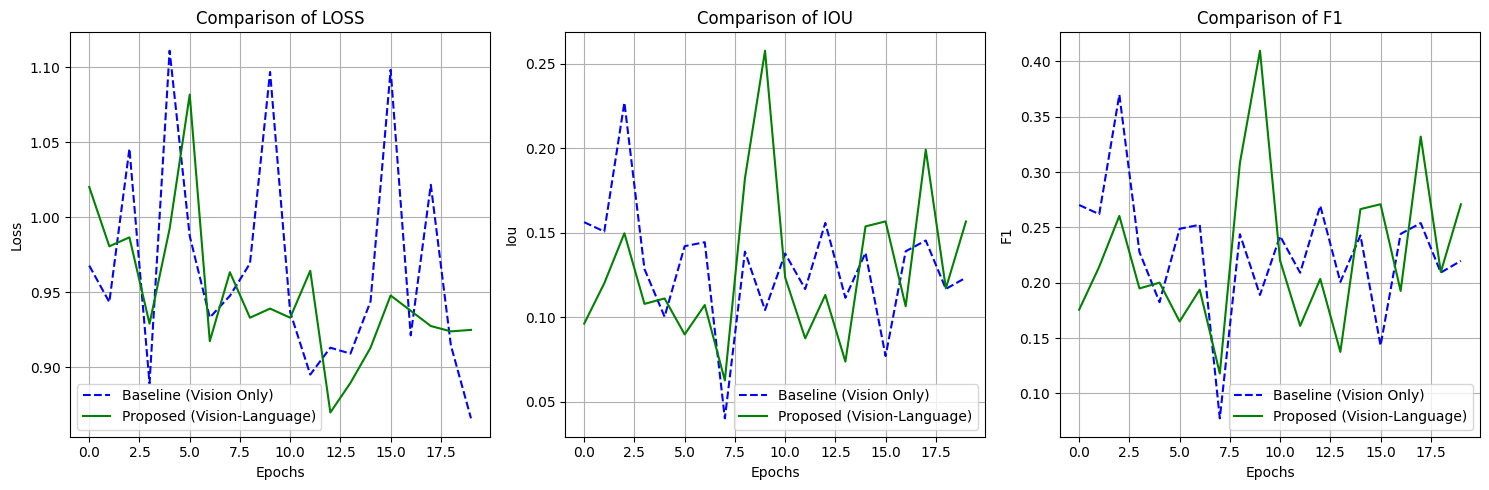

Results saved to: /content/drive/MyDrive/Google Colab/LRO_Project/model_comparison_visual_results.png


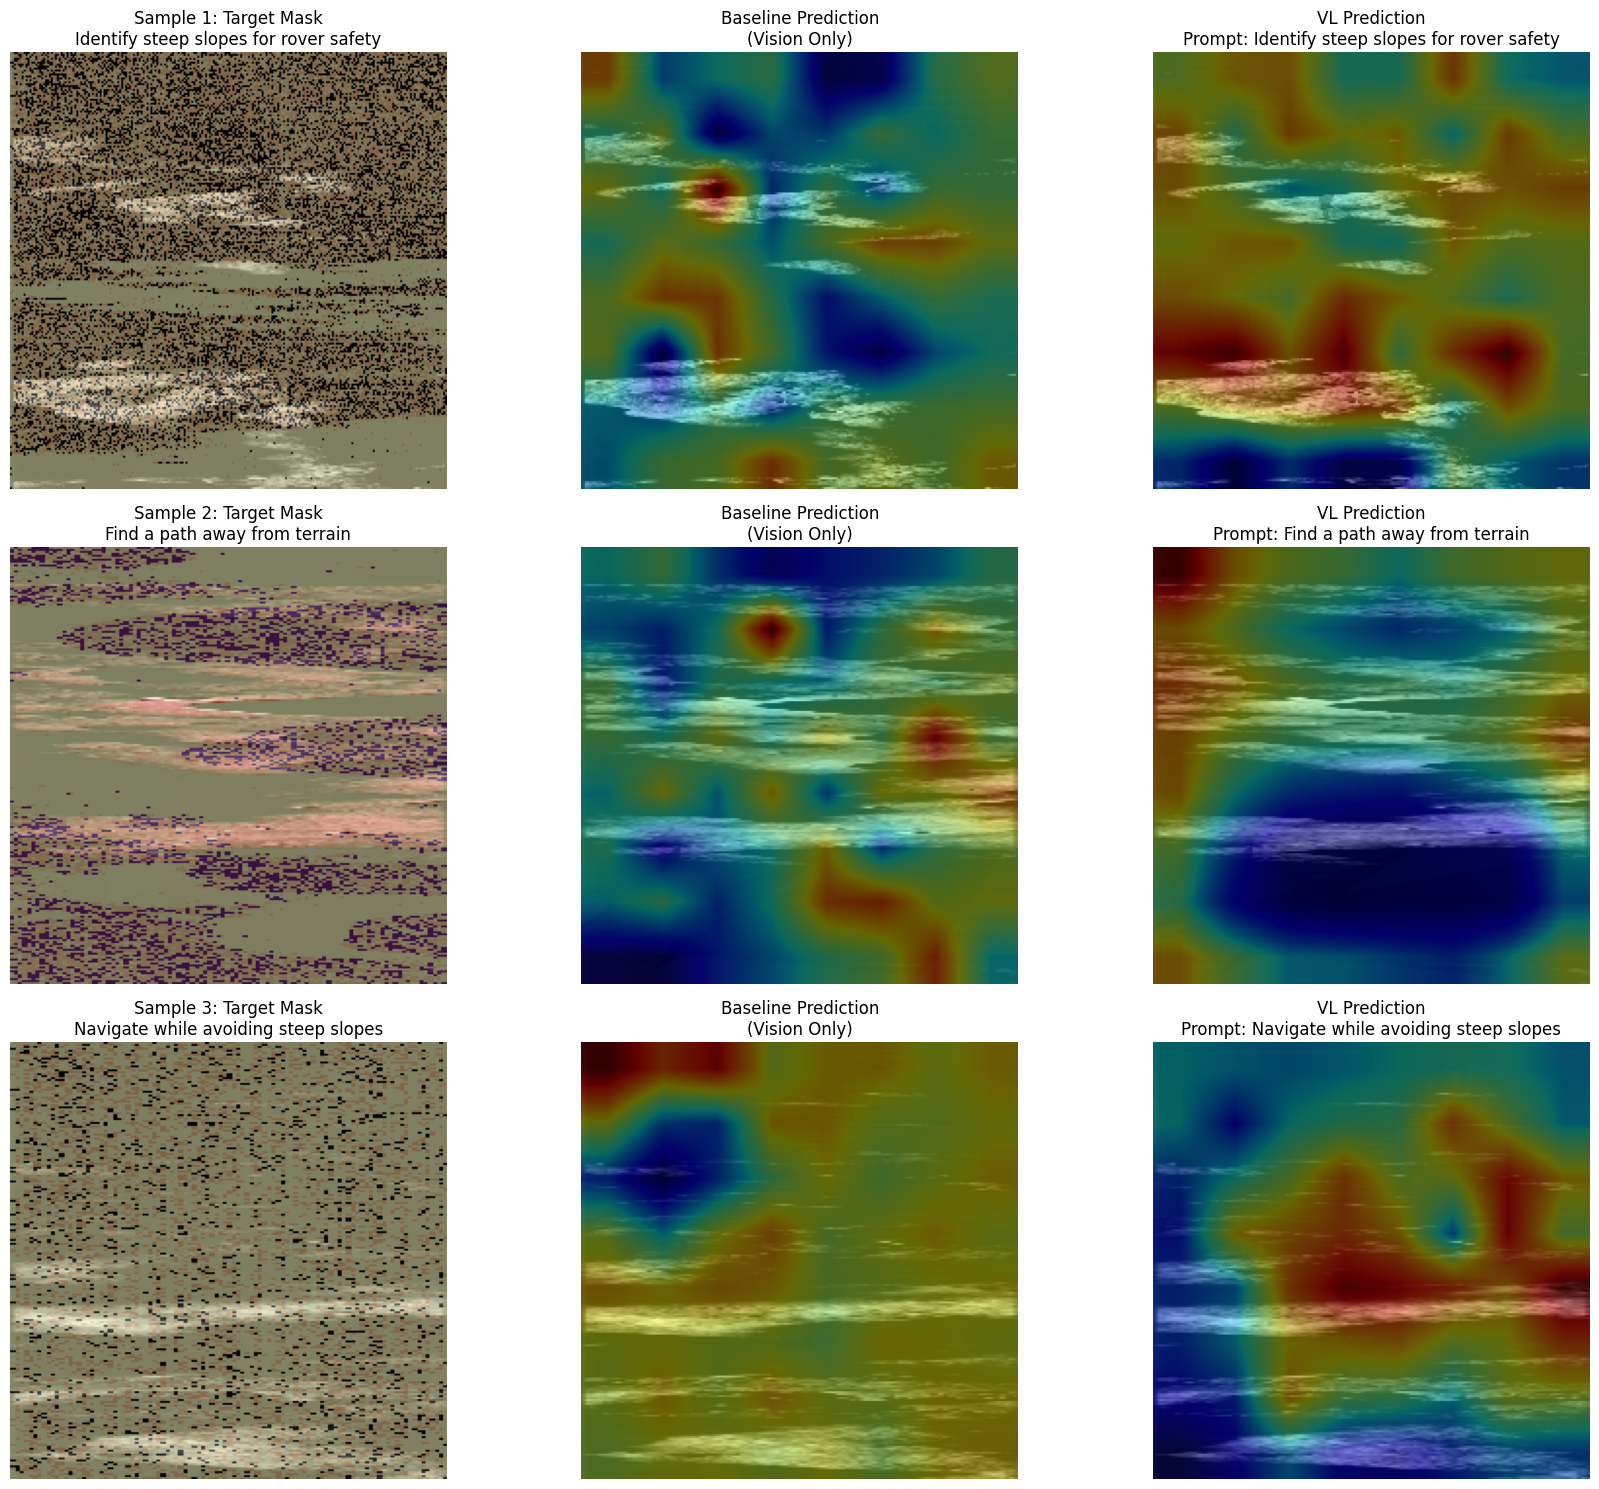

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPTokenizer
from segmentation_models_pytorch.decoders.unet.decoder import UnetDecoder

# Parameters
NUM_WORKERS = 0
BATCH_SIZE = 8
IMAGE_SIZE = 512
LEARNING_RATE = 0.0001
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch16")

dataset = LunarTerrainDataset(processed_img_paths, raw_img_paths, transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Initialize scaler
scaler = torch.amp.GradScaler('cuda')

model_baseline = VisionOnlyUNet().to(DEVICE)
model_vl = VLUNet().to(DEVICE)

criterion = DiceBCELoss()
results = {"baseline": [], "vl": []}

history = {
    "baseline": {"loss": [], "iou": [], "f1": []},
    "vl": {"loss": [], "iou": [], "f1": []}
}


for name, model in [("baseline", model_baseline), ("vl", model_vl)]:

  print(f"\n ---- Training for {name.upper()} Model ----")
  optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

  is_vl_flag = (name == "vl")

  for epoch in range(EPOCHS):

    avg_loss, iou, f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, tokenizer, scaler, is_vl_flag)
    history[name]["loss"].append(avg_loss)
    history[name]["iou"].append(iou)
    history[name]["f1"].append(f1)

    print(f"Epoch {epoch + 1}/{EPOCHS} Finished: mIoU = {iou:.4f}")

  # Save Weights
  torch.save(model.state_dict(), f"{save_path}/{name}_weights.pth")

  # Clear VRAM after each model runs
  del model
  del optimizer
  torch.cuda.empty_cache()



# Reload the weights
model_baseline = VisionOnlyUNet().to(DEVICE)
model_baseline.load_state_dict(torch.load(f"{save_path}/baseline_weights.pth"))
model_baseline.eval()

model_vl = VLUNet().to(DEVICE)
model_vl.load_state_dict(torch.load(f"{save_path}/vl_weights.pth"))
model_vl.eval()

# Plot & visualize results
plot_results(history)
visualize_nav_grid(model_vl, model_baseline, val_loader, DEVICE)




**Results Analysis**
****

Next steps:

Running the models on Mars Rover images

FeatureMap -> 3D action in simulated virtual environments

   -A* path planning navigation

  -7 DOF robot arm